In [1]:
# This is a simple tutorial that allow you to reproduce most types of figures.
# Before running this tutorial, please check any file paths are correct.

import os
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import kneighbors_graph

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["R_HOME"] = "/root/anaconda3/envs/PRAGA/lib/R"

import argparse
from preprocess import fix_seed, read_and_preprocess_data
from metrics import metric
from train import Train
from utils import clustering
from params import params

# Some parameters have been fixed in params.py.

class Args:
    def __init__(self):
        self.data_type = 'E15_5-S1'
        self.random_seed = 2024
        self.dim_output = 64
        self.epochs = 400
        self.device = 'cuda:0'
        self.tool = 'svd'
        self.pruning = False
        self.single = False

args = Args()
args = params(args)

fix_seed(args.random_seed)
data, adata_omics1 = read_and_preprocess_data(args)
model = Train(data, args)

/root/anaconda3/envs/PRAGA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [2]:
label, SVD_U, emb, z1, z2, z = model.train()
adata = adata_omics1.copy()
adata.obsm['SpaMEDM'] = emb.copy()
adata.obs['SpaMEDM'] = label
adata.obs['SpaMEDM'] = adata.obs.SpaMEDM.astype('category')
if args.tool != 'svd':
    clustering(adata, key='SpaMEDM', add_key='SpaMEDM', n_clusters=args.n_clusters, method=args.tool, use_pca=True)
metric(args, adata)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:14<00:00, 28.06it/s]


0 11
1 12
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
1949
1949
MI: 1.364668
NMI: 0.679069
AMI: 0.673919
V-measure: 0.679069
Homogeneity: 0.664585
Completeness: 0.694199
ARI: 0.659678
FMI: 0.725210


/root/anaconda3/envs/PRAGA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


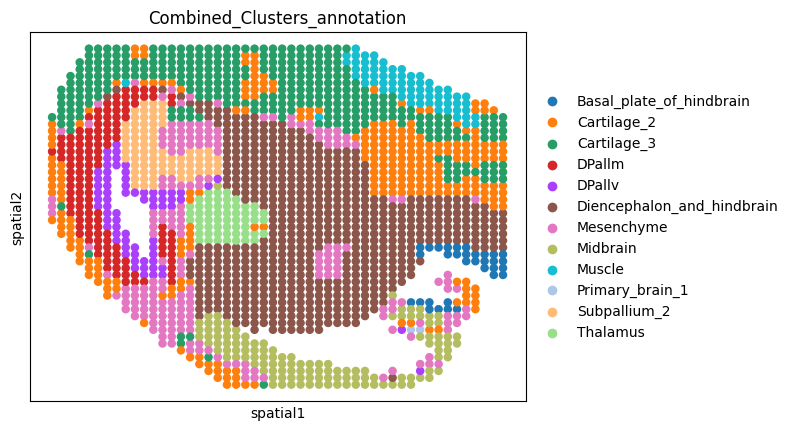

In [3]:
# We plot the ground truth
import scanpy as sc
adata_annotation = sc.read_h5ad("/remote-home/zhouchang/PRAGA/Data/other_data/Data/E15_5-S1/adata_RNA.h5ad")
adata_annotation.obsm['spatial'][:, 1] *= -1
sc.pl.embedding(adata_annotation, basis='spatial', color='Combined_Clusters_annotation', s=150)
colors = adata_annotation.uns['Combined_Clusters_annotation_colors']
ground_truth = adata_annotation.obs['Combined_Clusters_annotation']


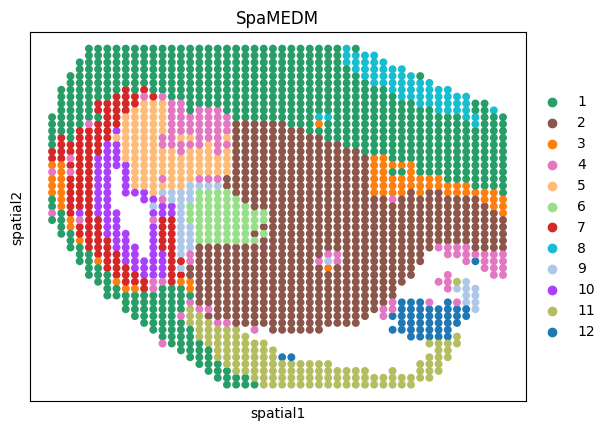

In [4]:
# We employ color mapping and plot identification result
import pandas as pd
from scipy.optimize import linear_sum_assignment
pred_labels = adata.obs['SpaMEDM'].cat.codes.astype('int64')
contingency_matrix = pd.crosstab(ground_truth.tolist(), pred_labels.tolist())
row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
mapping_dict = {contingency_matrix.columns[j]: contingency_matrix.index[i] for i, j in zip(row_ind, col_ind)}
unique_true_labels = np.unique(ground_truth)
color_map = {label: colors[i % len(colors)] for i, label in enumerate(unique_true_labels)}
unique_pred_labels = sorted(contingency_matrix.columns)
real_colors = []
for pred_label in unique_pred_labels:
    mapped_true_label = mapping_dict.get(pred_label)
    if mapped_true_label is not None:
        real_colors.append(color_map.get(mapped_true_label, '#808080'))
    else:
        print("Other color!")
        real_colors.append('#808080')
adata.obsm['spatial'][:, 1] *= -1
sc.pl.embedding(
    adata,
    basis="spatial",
    color='SpaMEDM',
    palette=real_colors,
    title="SpaMEDM",
    s=130,
)

/root/anaconda3/envs/PRAGA/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


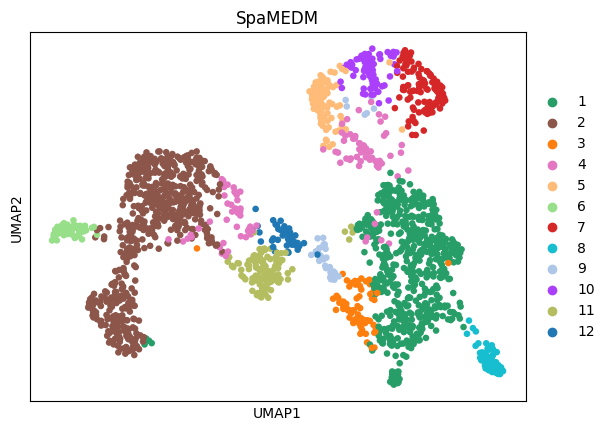

In [5]:
# We plot the UMAP result
sc.pp.neighbors(adata, use_rep='SpaMEDM', n_neighbors=50)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color='SpaMEDM',
    palette=real_colors,
    title='SpaMEDM',
    s=90,
)

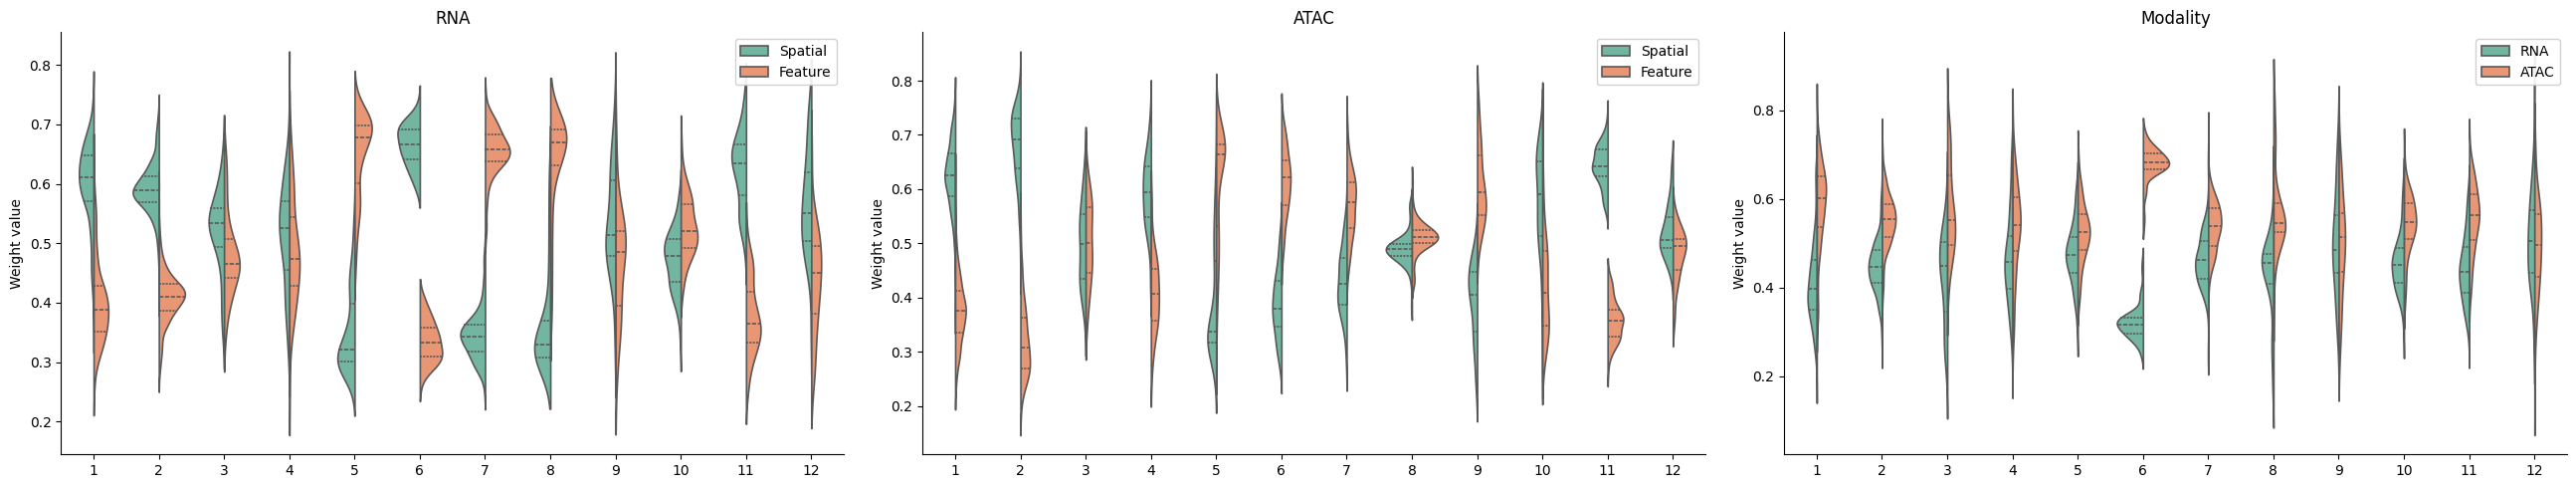

In [6]:
# We plot the attention weight distributions
import matplotlib.pyplot as plt
import seaborn as sns
adata.obsm['z1_spa_vs_fea'] = z1
adata.obsm['z2_spa_vs_fea'] = z2
adata.obsm['z1_vs_z2'] = z

cluster_numbers = pd.Categorical(label).codes + 1

plot_configs = [
    {
        'data': adata.obsm['z1_spa_vs_fea'],
        'modality_names': ['Spatial', 'Feature'],
        'title': 'RNA'
    },
    {
        'data': adata.obsm['z2_spa_vs_fea'],
        'modality_names': ['Spatial', 'Feature'],
        'title': 'ATAC'
    },
    {
        'data': adata.obsm['z1_vs_z2'],
        'modality_names': ['RNA', 'ATAC'],
        'title': 'Modality'
    }
]

fig, axes = plt.subplots(1, 3, figsize=(26, 5))

for i, config in enumerate(plot_configs):
    df = pd.DataFrame()
    df[config['modality_names'][0]] = config['data'][:, 0]
    df[config['modality_names'][1]] = config['data'][:, 1]

    df['Label'] = cluster_numbers
    df = df.set_index('Label').stack().reset_index()
    df.columns = ['Cluster_ID', 'Modality', 'Weight value']

    ordered_clusters = sorted(df['Cluster_ID'].unique())

    sns.violinplot(
        data=df,
        x='Cluster_ID',
        y='Weight value',
        hue='Modality',
        split=True,
        inner="quart",
        linewidth=1.2,
        ax=axes[i],
        palette="Set2",
        order=ordered_clusters
    )

    axes[i].set_title(config['title'])
    axes[i].set_xlabel('')

    axes[i].set_xticks(range(len(ordered_clusters)))
    axes[i].set_xticklabels([str(c) for c in ordered_clusters], rotation=0, ha='center')
    axes[i].tick_params(axis='x', bottom=True)

    axes[i].legend(loc='upper right', title=None, frameon=True, framealpha=0.9)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout(w_pad=2.0)
plt.show()

/root/anaconda3/envs/PRAGA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/root/anaconda3/envs/PRAGA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/root/anaconda3/envs/PRAGA/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


         Falling back to preprocessing with `sc.pp.pca` and default params.
categories: 1, 10, 11, etc.
var_group_labels: 2, 6, 7, etc.


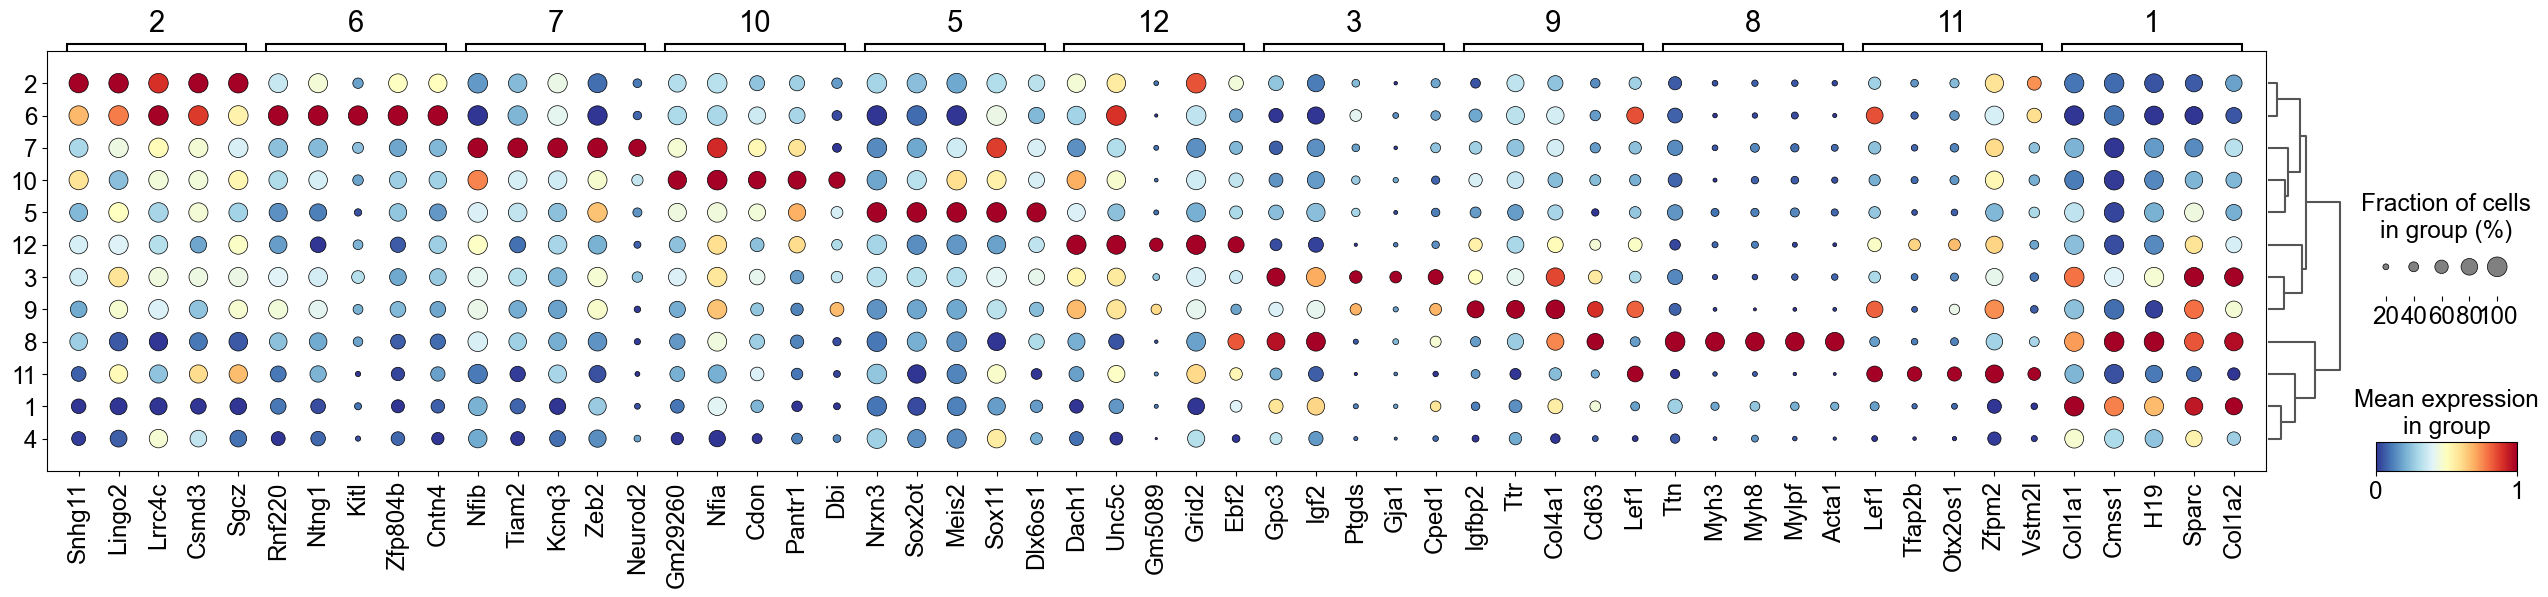

In [7]:
# We plot DEG dotplot figure
adata_rna = sc.read_h5ad("/remote-home/zhouchang/PRAGA/Data/other_data/Data/E15_5-S1/adata_RNA.h5ad")
adata_rna.obs['SpaMEDM'] = adata.obs['SpaMEDM'].values.astype(str)
adata_rna.obs['SpaMEDM'] = adata_rna.obs['SpaMEDM'].astype('category')
sc.pp.filter_genes(adata_rna, min_cells=50)
sc.pp.highly_variable_genes(adata_rna, flavor="seurat_v3", n_top_genes=3000)
adata_rna = adata_rna[:, adata_rna.var['highly_variable']]
adata_rna.var_names_make_unique()
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)

sc.tl.rank_genes_groups(adata_rna, groupby='SpaMEDM', method='wilcoxon')
marker_df = sc.get.rank_genes_groups_df(adata_rna, group=None)

sig_markers = marker_df[
    (marker_df['pvals_adj'] < 0.05) &
    (marker_df['logfoldchanges'] > 1.0)
    ]

top_genes_dict = {}
for cluster in adata_rna.obs['SpaMEDM'].cat.categories:
    cluster_genes = sig_markers[sig_markers['group'] == cluster]

    top5 = cluster_genes.head(5)['names'].tolist()

    if len(top5) > 0:
        top_genes_dict[cluster] = top5

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 21
plt.rcParams['axes.titlesize'] = 21

custom_order = ['2', '6', '7', '10', '5', '12', '3', '9', '8', '11', '1']

custom_top_genes_dict = {}

for cluster_id in custom_order:
    if cluster_id in top_genes_dict:
        custom_top_genes_dict[cluster_id] = top_genes_dict[cluster_id]


fig_dotplot = sc.pl.rank_genes_groups_dotplot(
    adata_rna,
    var_names=custom_top_genes_dict,
    groupby='SpaMEDM',
    standard_scale='var',
    cmap='RdYlBu_r',
    figsize=(26, 6),
    show=False,
    return_fig=True
)

fig_dotplot.style(cmap='RdYlBu_r', dot_edge_color='black', dot_edge_lw=0.5)
fig_dotplot.make_figure()

plt.subplots_adjust(
    bottom=0.20,
    top=0.90,
    left=0.03,
    right=0.98
)

plt.show()

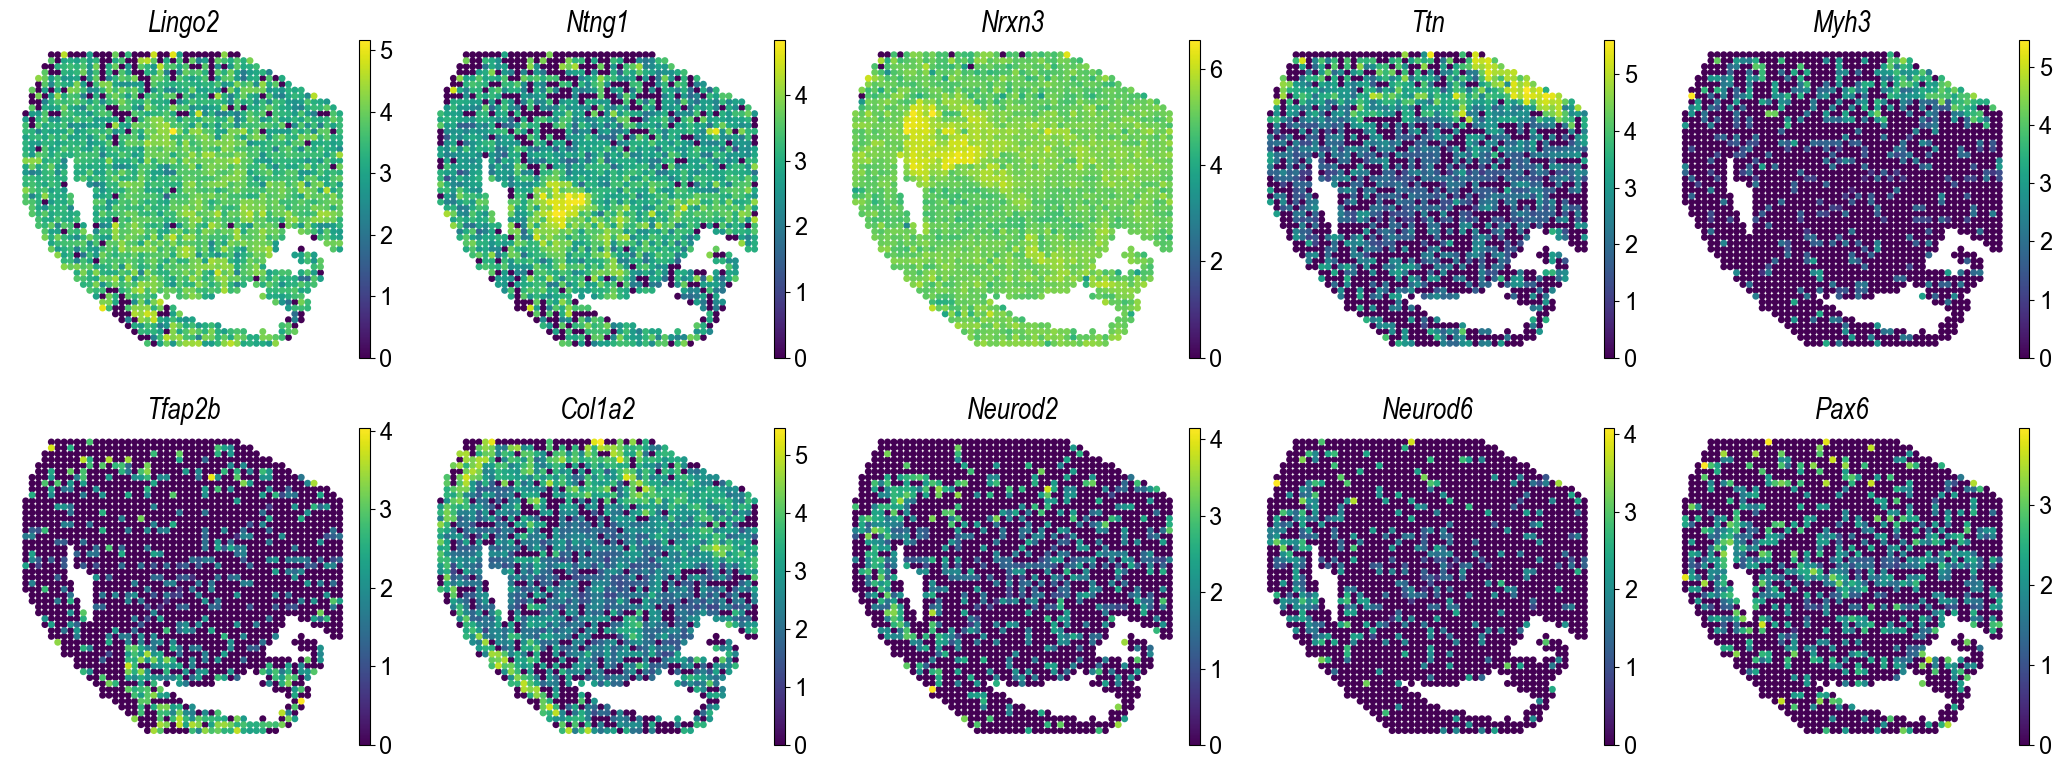

In [8]:
# We plot some gene expression panels
fig, axes = plt.subplots(2, 5, figsize=(21, 8))
axes = axes.ravel()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 17
genes = ['Lingo2', 'Ntng1', 'Nrxn3', 'Ttn', 'Myh3', 'Tfap2b', 'Col1a2', 'Neurod2', 'Neurod6', 'Pax6']
adata_rna.obsm['spatial'][:, 1] *= -1
for i, (gene, ax) in enumerate(zip(genes, axes)):
    sc.pl.embedding(
        adata_rna,
        basis='spatial',
        color=f"{gene}",
        title=f"{gene}$",
        show=False,
        ax=ax,
        frameon=False,
        legend_loc=None,
        s=100,
    )
    ax.set_title(f"{gene}", fontstyle='italic')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2187510/2724509111.py:9: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  ad_holder = sc.AnnData(dummy_matrix, obsm={'spatial': adata.obsm['spatial']})
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 151.01/s]
/tmp/ipykernel_2187510/2724509111.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


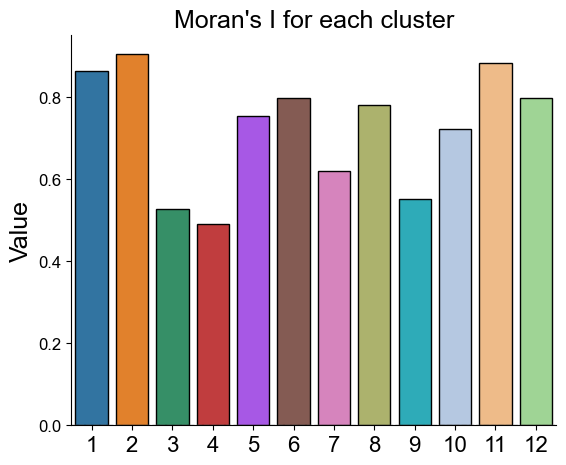

In [9]:
# We plot Moran's I figure
import squidpy as sq
import re
def calculate_cluster_morans(adata, cluster_col, coord_type='generic', **kwargs):
    dummies = pd.get_dummies(adata.obs[cluster_col])
    dummy_matrix = dummies.astype(float).values
    cluster_names = dummies.columns.astype(str).tolist()

    ad_holder = sc.AnnData(dummy_matrix, obsm={'spatial': adata.obsm['spatial']})
    ad_holder.var_names = cluster_names
    sq.gr.spatial_neighbors(ad_holder, coord_type=coord_type, **kwargs)

    sq.gr.spatial_autocorr(
        ad_holder,
        mode="moran",
        genes=cluster_names,
        n_perms=1000,
        n_jobs=6,
    )
    return ad_holder.uns["moranI"]

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', str(s))]

moran_df = calculate_cluster_morans(adata, 'SpaMEDM')
sorted_index = sorted(moran_df.index, key=natural_sort_key)
moran_df = moran_df.loc[sorted_index]

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 18

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    x=moran_df.index,
    y=moran_df['I'],
    ax=ax,
    edgecolor='black',
    linewidth=1,
    palette = colors
)

y_max = moran_df['I'].max()
offset = y_max * 0.05

p_col = 'pval_sim' if 'pval_sim' in moran_df.columns else 'pval_norm'

for idx, cluster in enumerate(moran_df.index):
    i_val = moran_df.loc[cluster, 'I']
    p_val = moran_df.loc[cluster, p_col]

    if p_val > 0.05:
        ax.text(
            idx,
            max(i_val, 0) + offset,
            'ns',
            ha='center',
            va='bottom',
            fontsize=12,
        )

ax.set_title(f"Moran's I for each cluster")
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Value")

ax.axhline(0, color='grey', linestyle='--', linewidth=1)

plt.xticks(fontsize=16)
plt.yticks(fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2187510/293632766.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


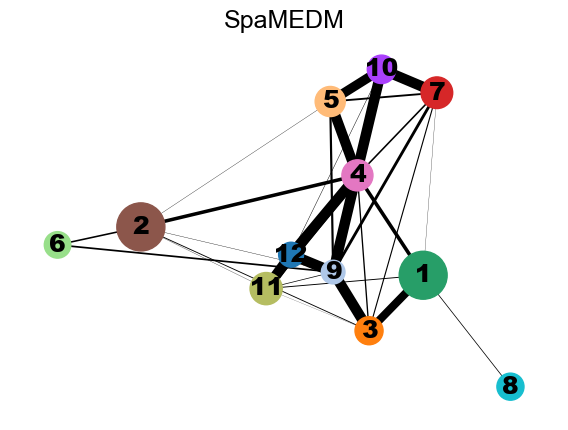

In [10]:
# We plot PAGA
sc.tl.paga(adata, groups="SpaMEDM")
clusters = adata.obs['SpaMEDM'].cat.categories
cluster_centers_umap = np.array([
    np.median(adata.obsm['X_umap'][adata.obs['SpaMEDM'] == cluster], axis=0)
    for cluster in clusters
])
adata.uns['paga']['pos'] = cluster_centers_umap
adata.uns['SpaMEDM_colors'] = real_colors
sc.pl.paga(
    adata,
    color='SpaMEDM',
    pos=adata.uns['paga']['pos'],
    title='SpaMEDM',
    show=False,
    frameon=False,
    fontsize=18,
    node_size_scale=3.0,
)
plt.tight_layout()
plt.show()

SpaMEDM ARI 0.6121734156622745 0.02409265946377175
SpaMEDM NMI 0.6196524574413044 0.03266508097837544
SpaMEDM FMI 0.6829233686336773 0.021826126636584745
SpaMEDM AMI 0.6136526285260455 0.03307398146356665
SpaMEDM V-measure 0.6196524574413044 0.03266508097837546


/tmp/ipykernel_2187510/3554422915.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


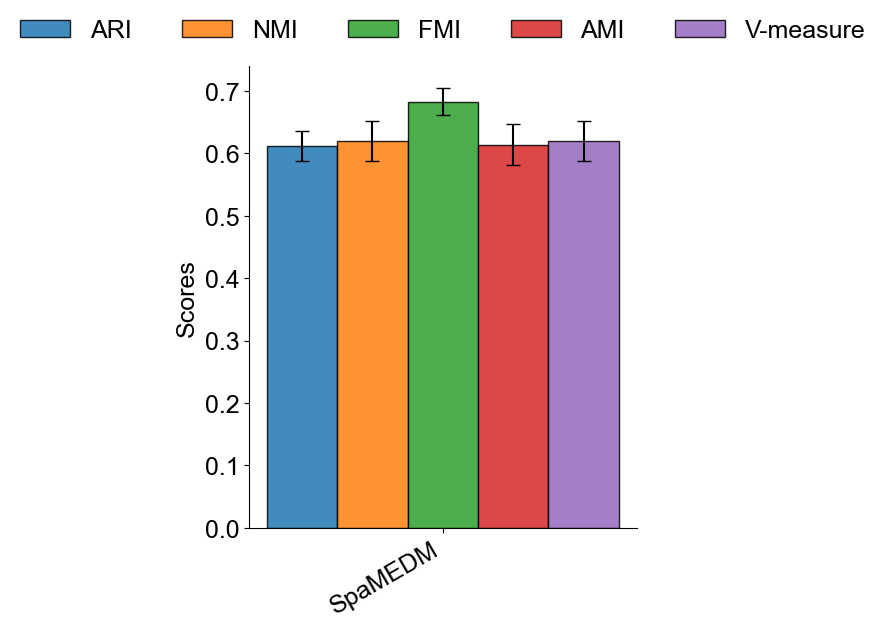

In [11]:
# We plot metrics with mean and std
# Here, the adata contains the results of seven repeated runs, which can be downloaded from "results" folder
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    fowlkes_mallows_score,
    v_measure_score
)

methods = ['SpaMEDM']
paths = ['/remote-home/zhouchang/PRAGA/SpaNodeDGI/new_results/adata_E15_5-S1.h5ad'] # 'SpaNodeDGI' is the previous version of SpaMEDM
# You can add your results here for comparison

metrics_names = ['ARI', 'NMI', 'FMI', 'AMI', 'V-measure']

results = {method: {m: [] for m in metrics_names} for method in methods}

for i, path in enumerate(paths):
    method = methods[i]
    try:
        temp_adata = sc.read_h5ad(path)
    except FileNotFoundError:
        print(f"Not found {method} -> {path}")
        continue

    seed_cols = [col for col in temp_adata.obs.columns if col != 'Combined_Clusters_annotation']
    assert len(seed_cols) == 7

    for col in seed_cols[:7]:
        y_pred = temp_adata.obs[col].values

        y_true_aligned = ground_truth
        y_pred_aligned = y_pred

        results[method]['ARI'].append(adjusted_rand_score(y_true_aligned, y_pred_aligned))
        results[method]['NMI'].append(normalized_mutual_info_score(y_true_aligned, y_pred_aligned))
        results[method]['FMI'].append(fowlkes_mallows_score(y_true_aligned, y_pred_aligned))
        results[method]['AMI'].append(adjusted_mutual_info_score(y_true_aligned, y_pred_aligned))
        results[method]['V-measure'].append(v_measure_score(y_true_aligned, y_pred_aligned))

means = {m: [] for m in metrics_names}
stds = {m: [] for m in metrics_names}

for method in methods:
    for m in metrics_names:
        val_list = results[method][m]
        if len(val_list) > 0:
            print(method, m ,np.mean(val_list), np.std(val_list))
            means[m].append(np.mean(val_list))
            stds[m].append(np.std(val_list))
        else:
            means[m].append(0)
            stds[m].append(0)

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 18

fig, ax = plt.subplots(figsize=(5, 6))

x = np.arange(len(methods))
width = 0.15
multiplier = 0

colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, m in enumerate(metrics_names):
    offset = width * multiplier
    ax.bar(
        x + offset,
        means[m],
        width,
        label=m,
        yerr=stds[m],
        capsize=5,
        color=colors_bar[i],
        edgecolor='black',
        alpha=0.85
    )
    multiplier += 1

ax.set_xticks(x + width * 2)
ax.set_xticklabels(methods, rotation=30, ha='right')

ax.set_ylabel('Scores')
ax.set_title('')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=5, frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
print("Thank you for reading! 🙏")

Thank you for reading! 🙏
